# Task 4 (Medium) - Netflix Content Segmentation
**Auspify Technologies - Machine Learning Internship**

Groups Netflix titles into meaningful clusters using unsupervised machine
learning (K-Means), based on numerical and categorical content attributes.

Workflow:

  Step 1: Prepare numerical and categorical features.
  
  Step 2: Apply clustering algorithms.
  
  Step 3: Identify content groups.
  
  Step 4: Visualize clusters.
  
  Step 5: Interpret cluster characteristics.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.metrics import silhouette_score

DATA_PATH = "Dataset.csv"
RANDOM_STATE = 42
BUSINESS_K = 6

def prepare_features(path):
    """
    Step 1 (Final Model): Pure content-based features.
    Excludes 'type' and 'duration_value' to prevent K-Means from artificially 
    splitting data along the Movie vs TV Show boundary.
    """
    df = pd.read_csv(path)
    for col in ["director", "country", "listed_in", "rating"]:
        df[col] = df[col].fillna("")

    # Reference metadata used for interpretation steps
    df["primary_genre"] = df["listed_in"].apply(lambda x: x.split(",")[0].strip() if x else "Unknown")
    df["primary_country"] = df["country"].apply(lambda x: x.split(",")[0].strip() if x else "Unknown")
    
    # 1. Multi-genre handling via MultiLabelBinarizer + TruncatedSVD
    genre_lists = df["listed_in"].apply(lambda x: [g.strip() for g in x.split(",")] if x else [])
    mlb = MultiLabelBinarizer()
    genre_matrix = mlb.fit_transform(genre_lists)

    svd = TruncatedSVD(n_components=8, random_state=RANDOM_STATE)
    genre_embedding = svd.fit_transform(genre_matrix)

    # 2. Format-neutral numerical features (excluding 'type' and 'duration_value')
    numeric = pd.DataFrame({
        "release_year": df["release_year"],
        "is_international": (df["country"].str.contains(",")).astype(int),
    })
    
    # Feature scaling
    scaled_numeric = StandardScaler().fit_transform(numeric)
    
    # Merge scaled numeric features with genre embeddings
    scaled = np.hstack([scaled_numeric, genre_embedding])
    
    print(f"Genre SVD explained variance ratio (8 components): {svd.explained_variance_ratio_.sum():.3f}")
    return df, scaled

def find_optimal_k(scaled_features, k_range=range(2, 9)):
    """Step 2a: elbow + silhouette curve across k=2..8."""
    inertias, silhouettes = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(scaled_features)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(scaled_features, labels))
        print(f"  k={k}: inertia={km.inertia_:.1f}, silhouette={silhouettes[-1]:.4f}")

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1); plt.plot(list(k_range), inertias, marker="o")
    plt.title("Elbow Method"); plt.xlabel("k"); plt.ylabel("Inertia")
    plt.subplot(1, 2, 2); plt.plot(list(k_range), silhouettes, marker="o", color="orange")
    plt.title("Silhouette Score"); plt.xlabel("k"); plt.ylabel("Score")
    plt.tight_layout(); plt.savefig("cluster_elbow.png", dpi=120); plt.show()

    best_by_silhouette = list(k_range)[int(np.argmax(silhouettes))]
    print(f"Best k by silhouette alone: {best_by_silhouette} (broad macro-clusters)")
    print(f"Chosen k for granular business segmentation: {BUSINESS_K}")
    return BUSINESS_K

def interpret_clusters(df_with_clusters):
    """Step 5: per-cluster profile summary."""
    print("\nCluster profiles:")
    for cid in sorted(df_with_clusters["cluster"].unique()):
        s = df_with_clusters[df_with_clusters["cluster"] == cid]
        top_genre = s["primary_genre"].mode().iloc[0] if not s["primary_genre"].mode().empty else "N/A"
        top_country = s["primary_country"].mode().iloc[0] if not s["primary_country"].mode().empty else "N/A"
        top_type = s["type"].mode().iloc[0] if not s["type"].mode().empty else "N/A"
        print(f"  Cluster {cid} (n={len(s)}): mostly '{top_type}', "
              f"top genre '{top_genre}', top country '{top_country}', "
              f"avg release year {s['release_year'].mean():.0f}")

def apply_kmeans(scaled_features, k):
    """Fits the final K-Means model with the chosen k."""
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(scaled_features)
    return model, labels

def identify_groups(df, labels):
    """Assigns cluster labels back to the dataframe and displays cluster sizes."""
    df_copy = df.copy()
    df_copy["cluster"] = labels
    print("Cluster sizes:")
    print(df_copy["cluster"].value_counts().sort_index())
    return df_copy

def visualize_clusters(scaled_features, labels):
    """Visualizes clusters using a 2D PCA projection."""
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    coords = pca.fit_transform(scaled_features)
    
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(coords[:, 0], coords[:, 1], c=labels, cmap="tab10", alpha=0.6, s=10)
    plt.title("Netflix Content Clusters (PCA Projection)")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.colorbar(scatter, label="Cluster ID")
    plt.tight_layout()
    plt.savefig("cluster_visualization.png", dpi=120)
    plt.show()
    print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")


## Step 1: Prepare numerical and genre-aware categorical features

In [7]:
df, scaled = prepare_features(DATA_PATH)
print(f"Feature matrix shape: {scaled.shape}")

Genre SVD explained variance ratio (8 components): 0.587
Feature matrix shape: (8790, 10)


## Step 2: Apply clustering - elbow/silhouette curve, then choose business k

  k=2: inertia=12714.6, silhouette=0.5188
  k=3: inertia=10281.9, silhouette=0.2571
  k=4: inertia=8951.1, silhouette=0.2616
  k=5: inertia=7780.7, silhouette=0.2557
  k=6: inertia=6898.3, silhouette=0.2816
  k=7: inertia=6254.2, silhouette=0.3086
  k=8: inertia=5730.7, silhouette=0.3176


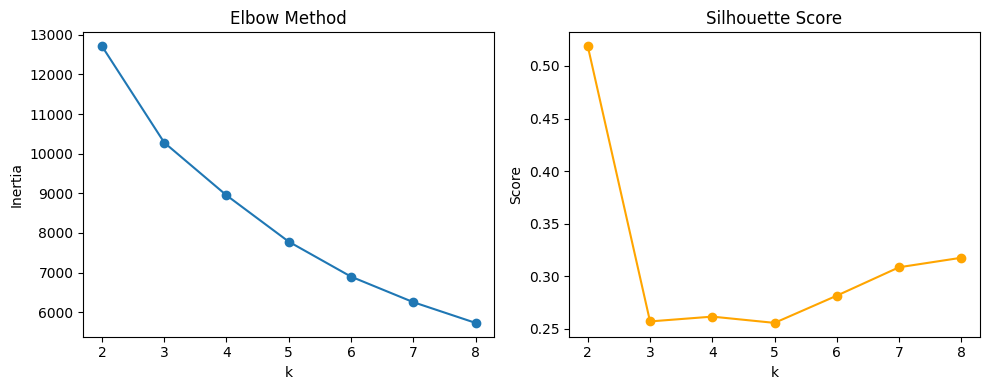

Best k by silhouette alone: 2 (broad macro-clusters)
Chosen k for granular business segmentation: 6


In [8]:
best_k = find_optimal_k(scaled)

## Step 3: Fit final K-Means & identify content groups

In [9]:
model, labels = apply_kmeans(scaled, best_k)
df_with_clusters = identify_groups(df, labels)

Cluster sizes:
cluster
0    1503
1    3238
2     217
3    1636
4     831
5    1365
Name: count, dtype: int64


## Step 4: Visualize clusters (PCA projection)

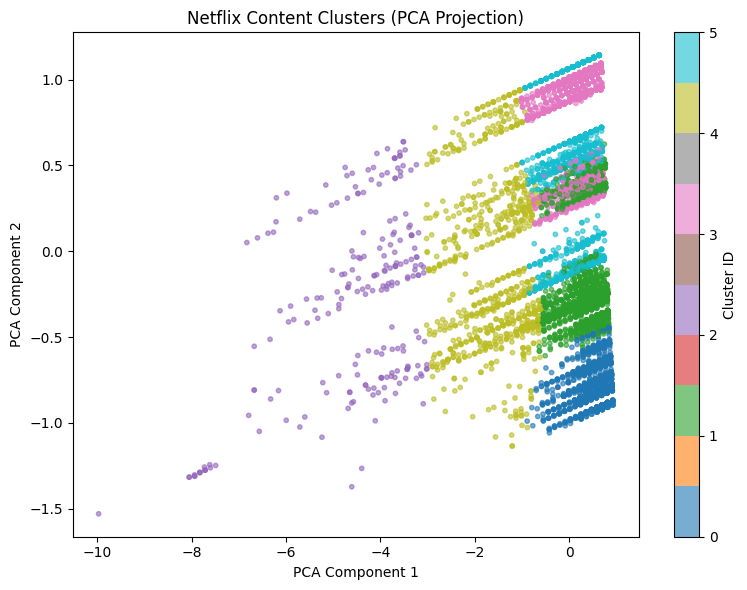

PCA explained variance ratio: [0.48173165 0.16545828]


In [10]:
visualize_clusters(scaled, labels)

## Step 5: Interpret cluster characteristics

In [11]:
interpret_clusters(df_with_clusters)


Cluster profiles:
  Cluster 0 (n=1503): mostly 'TV Show', top genre 'International TV Shows', top country 'Pakistan', avg release year 2017
  Cluster 1 (n=3238): mostly 'Movie', top genre 'Documentaries', top country 'United States', avg release year 2017
  Cluster 2 (n=217): mostly 'Movie', top genre 'Action & Adventure', top country 'United States', avg release year 1974
  Cluster 3 (n=1636): mostly 'Movie', top genre 'Dramas', top country 'United States', avg release year 2016
  Cluster 4 (n=831): mostly 'Movie', top genre 'Action & Adventure', top country 'United States', avg release year 2001
  Cluster 5 (n=1365): mostly 'Movie', top genre 'Comedies', top country 'United States', avg release year 2016



## Final Model

The third version is used as the final clustering model because it addresses the main methodological issue identified in the previous approach.

### Feature Selection

The `type` and `duration_value` features were excluded from the final model. Including these variables could cause K-Means to reproduce the existing Movie vs TV Show distinction instead of discovering meaningful content-based segments.

The final feature matrix therefore focuses on content-related attributes:

- **Genre information:** represented using Multi-Hot Encoding and reduced using Truncated SVD (8 components).
- **Release year:** captures the temporal characteristics of the content.
- **International production:** indicates whether a title is associated with multiple countries.

```python
numeric = pd.DataFrame({
    "release_year": df["release_year"],
    "is_international": (df["country"].str.contains(",")).astype(int),
})

```